# 01 - Filtros Classicos: HP, BK e CF — SOLUTION

**Versao completa com todos os exercicios resolvidos e outputs salvos.**

Este notebook contem:
1. Teoria e implementacao dos filtros HP, BK e CF
2. Analise de sensibilidade dos parametros
3. Validacao com dados sinteticos
4. **Exercicios resolvidos** com PIB dos EUA e Brasil
5. **Correlacao entre ciclos** extraidos por diferentes filtros
6. **Outputs salvos** em `outputs/`

## 1. Setup e Carregamento dos Dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import sys
import os

# Adicionar o diretorio raiz do projeto ao path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Imports do chronobox
from chronobox.filters import hp_filter, bk_filter, cf_filter

# Helpers
sys.path.insert(0, os.path.join(project_root, 'examples', 'filters'))
from utils.plot_helpers import plot_trend_cycle, plot_bandpass_comparison
from utils.data_generators import generate_trend_cycle

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

# Diretorio de outputs
output_dir = os.path.join(project_root, 'examples', 'filters', 'outputs')
os.makedirs(output_dir, exist_ok=True)

print('Setup completo!')

Setup completo!


In [2]:
# Carregar PIB real dos EUA (trimestral, 1970-)
data_dir = os.path.join(project_root, 'examples', 'filters', 'data')
us_gdp = pd.read_csv(os.path.join(data_dir, 'us_gdp_quarterly.csv'), parse_dates=['date'])

print(f'Periodo: {us_gdp["date"].iloc[0].date()} a {us_gdp["date"].iloc[-1].date()}')
print(f'Observacoes: {len(us_gdp)}')
print(f'\nPrimeiras linhas:')
us_gdp.head()

Periodo: 1970-01-01 a 2019-10-01
Observacoes: 200

Primeiras linhas:


,date,gdp_real,gdp_log
0,1970-01-01,2026.06,7.613848
1,1970-04-01,2033.90,7.617709
2,1970-07-01,2056.69,7.628853
3,1970-10-01,2080.76,7.640489
4,1971-01-01,2080.79,7.640504


## 2. Filtro Hodrick-Prescott (HP)

O filtro HP decompoe a serie $y_t$ em tendencia $\tau_t$ e ciclo $c_t = y_t - \tau_t$,
resolvendo o problema de minimizacao:

$$\min_{\tau_t} \left\{ \sum_{t=1}^{T} (y_t - \tau_t)^2 + \lambda \sum_{t=2}^{T-1} [(\tau_{t+1} - \tau_t) - (\tau_t - \tau_{t-1})]^2 \right\}$$

Valores convencionais: $\lambda = 1600$ (trimestral), $6.25$ (anual), $129600$ (mensal).

In [3]:
# HP filter com lambda=1600 (padrao trimestral)
y = us_gdp['gdp_log'].values
dates = us_gdp['date']

hp_trend, hp_cycle = hp_filter(y, lamb=1600)

print(f'HP Filter (lambda=1600)')
print(f'  Desvio padrao do ciclo: {hp_cycle.std():.4f}')
print(f'  Min ciclo: {hp_cycle.min():.4f}')
print(f'  Max ciclo: {hp_cycle.max():.4f}')

HP Filter (lambda=1600)
  Desvio padrao do ciclo: 0.0038
  Min ciclo: -0.0150
  Max ciclo: 0.0105


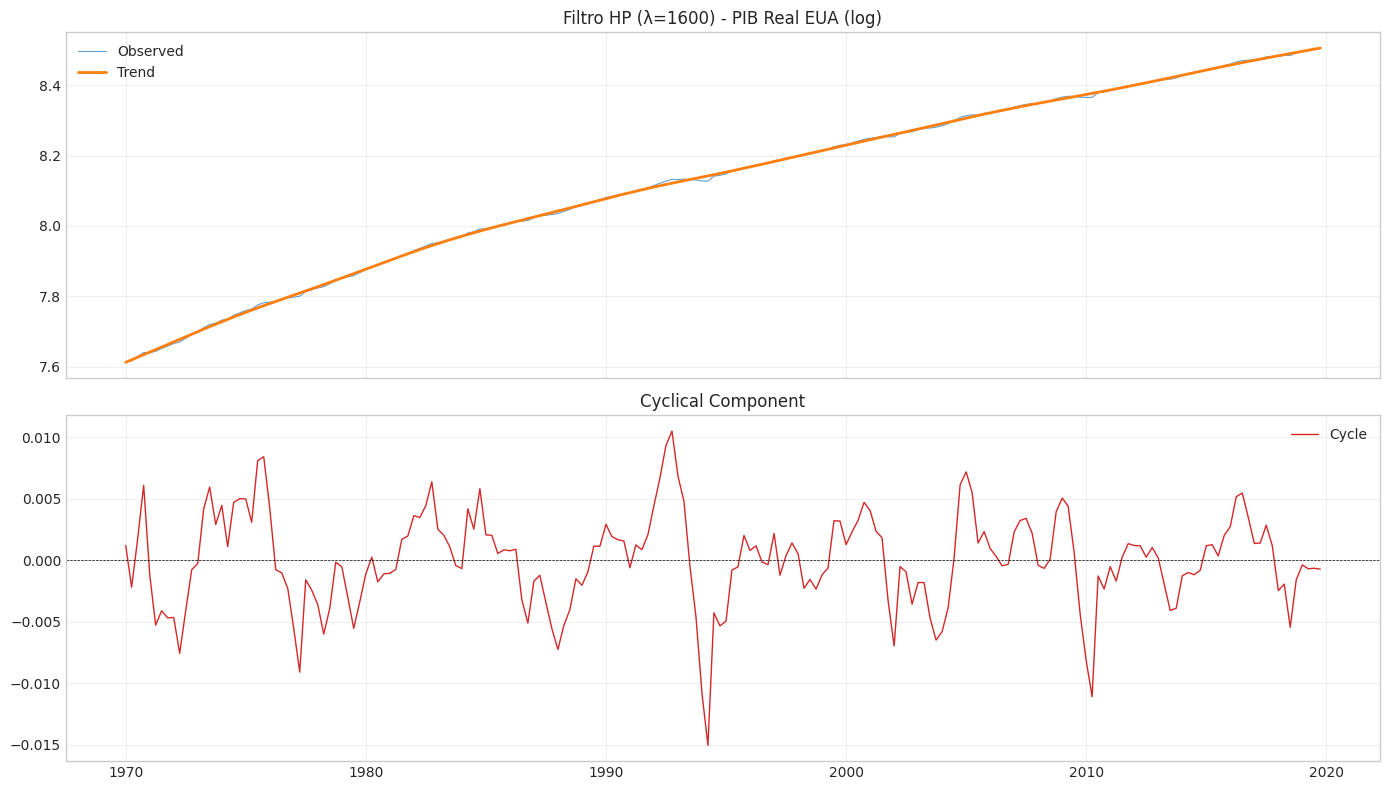

In [4]:
# Grafico: Decomposicao HP do PIB dos EUA
fig = plot_trend_cycle(
    dates, y, hp_trend, hp_cycle,
    title='Filtro HP (\u03bb=1600) - PIB Real EUA (log)'
)
plt.show()

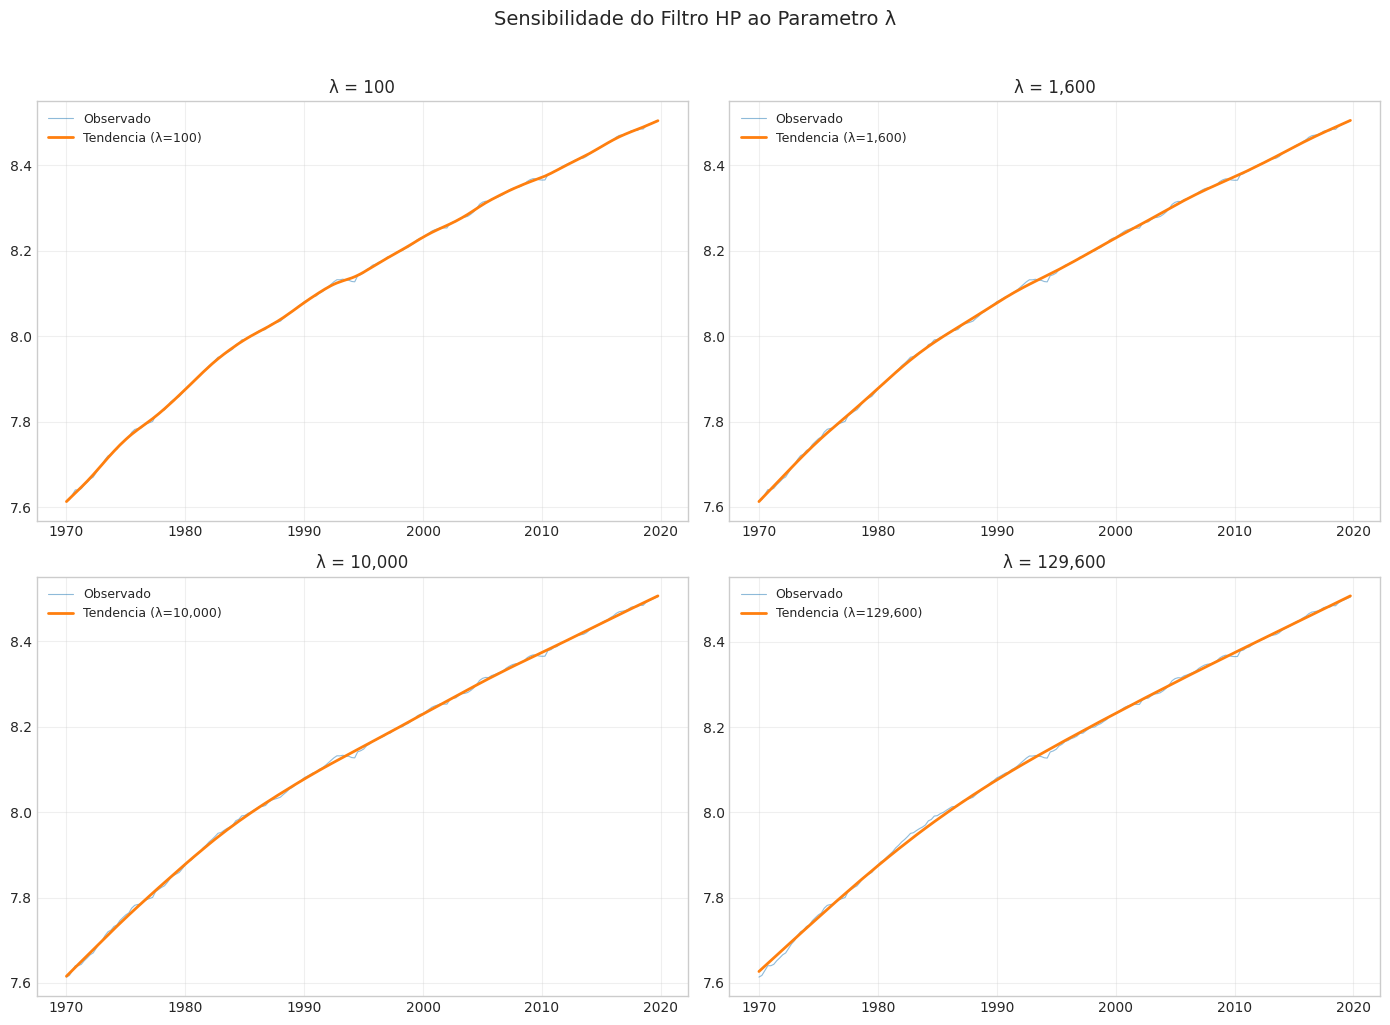

Desvio padrao do ciclo por lambda:
  λ=    100: std(ciclo) = 0.0027
  λ=  1,600: std(ciclo) = 0.0038
  λ= 10,000: std(ciclo) = 0.0045
  λ=129,600: std(ciclo) = 0.0060


In [5]:
# Sensibilidade ao parametro lambda
lambdas = [100, 1600, 10000, 129600]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, lam in enumerate(lambdas):
    trend_i, cycle_i = hp_filter(y, lamb=lam)
    axes[i].plot(dates, y, alpha=0.5, label='Observado', linewidth=0.8)
    axes[i].plot(dates, trend_i, label=f'Tendencia (\u03bb={lam:,})', linewidth=2)
    axes[i].set_title(f'\u03bb = {lam:,}')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

fig.suptitle('Sensibilidade do Filtro HP ao Parametro \u03bb', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Desvio padrao do ciclo por lambda:')
for lam in lambdas:
    _, c = hp_filter(y, lamb=lam)
    print(f'  \u03bb={lam:>7,}: std(ciclo) = {c.std():.4f}')

## 3. Filtro Baxter-King (BK)

Band-pass filter simetrico que isola flutuacoes entre `low` e `high` periodos.
Perde $2K$ observacoes nas bordas.

In [6]:
# BK filter: ciclos entre 6 e 32 trimestres, truncamento K=12
bk_cycle = bk_filter(y, low=6, high=32, trunc=12)

K = 12
print(f'BK Filter (low=6, high=32, trunc={K})')
print(f'  Obs originais: {len(y)}')
print(f'  Obs apos filtro: {len(bk_cycle)} (perdeu {2*K} nas bordas)')
print(f'  Desvio padrao do ciclo: {bk_cycle.std():.4f}')

BK Filter (low=6, high=32, trunc=12)
  Obs originais: 200
  Obs apos filtro: 176 (perdeu 24 nas bordas)
  Desvio padrao do ciclo: 0.0034


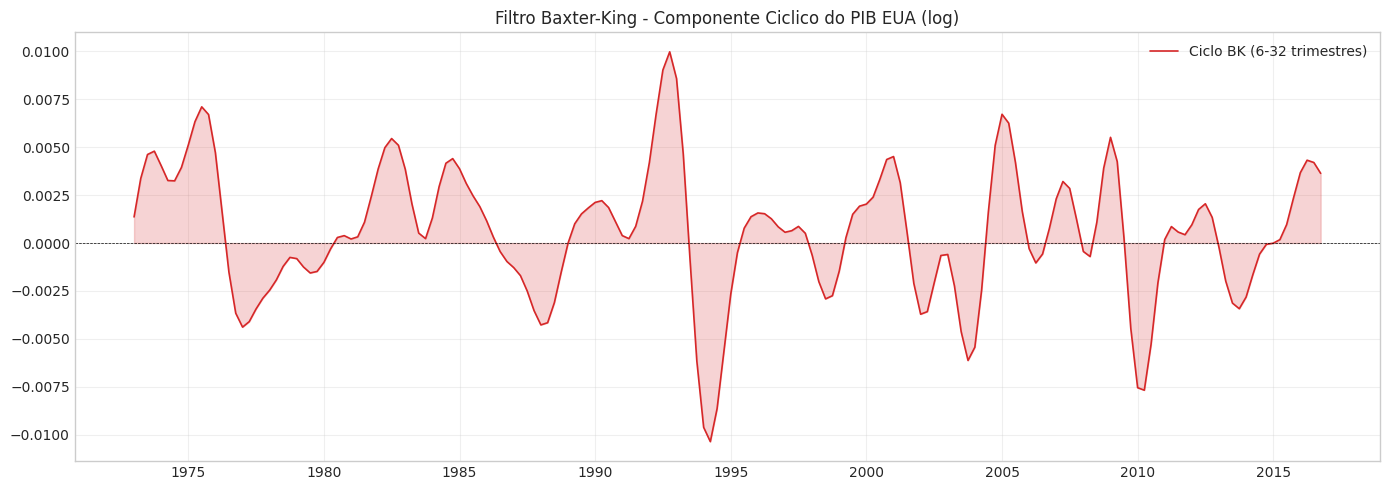

In [7]:
# Grafico: Ciclo BK
bk_dates = dates.iloc[K:-K]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(bk_dates, bk_cycle, label='Ciclo BK (6-32 trimestres)', color='tab:red', linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.fill_between(bk_dates, bk_cycle, 0, alpha=0.2, color='tab:red')
ax.set_title('Filtro Baxter-King - Componente Ciclico do PIB EUA (log)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Filtro Christiano-Fitzgerald (CF)

Band-pass assimetrico full-sample: usa todas as observacoes, sem perda nas bordas.

In [8]:
# CF filter: mesma banda de 6-32 trimestres
cf_cycle = cf_filter(y, low=6, high=32, drift=False)

print(f'CF Filter (low=6, high=32)')
print(f'  Obs originais: {len(y)}')
print(f'  Obs apos filtro: {len(cf_cycle)} (sem perda!)')
print(f'  Desvio padrao do ciclo: {cf_cycle.std():.4f}')

CF Filter (low=6, high=32)
  Obs originais: 200
  Obs apos filtro: 200 (sem perda!)
  Desvio padrao do ciclo: 0.0131


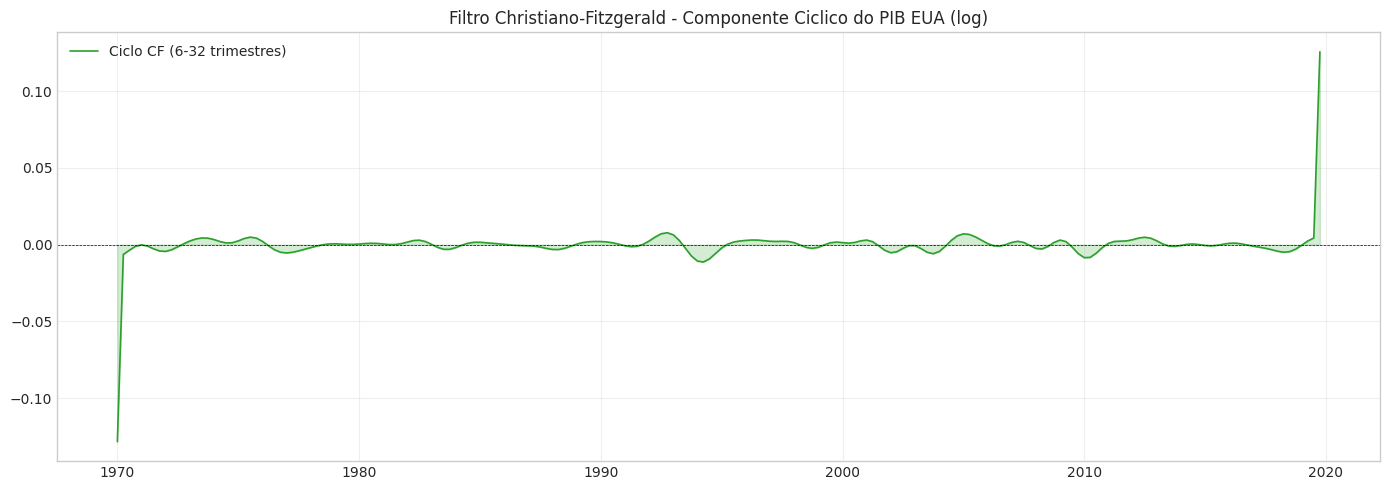

In [9]:
# Grafico: Ciclo CF
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates, cf_cycle, label='Ciclo CF (6-32 trimestres)', color='tab:green', linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.fill_between(dates, cf_cycle, 0, alpha=0.2, color='tab:green')
ax.set_title('Filtro Christiano-Fitzgerald - Componente Ciclico do PIB EUA (log)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Comparacao Visual: HP vs BK vs CF

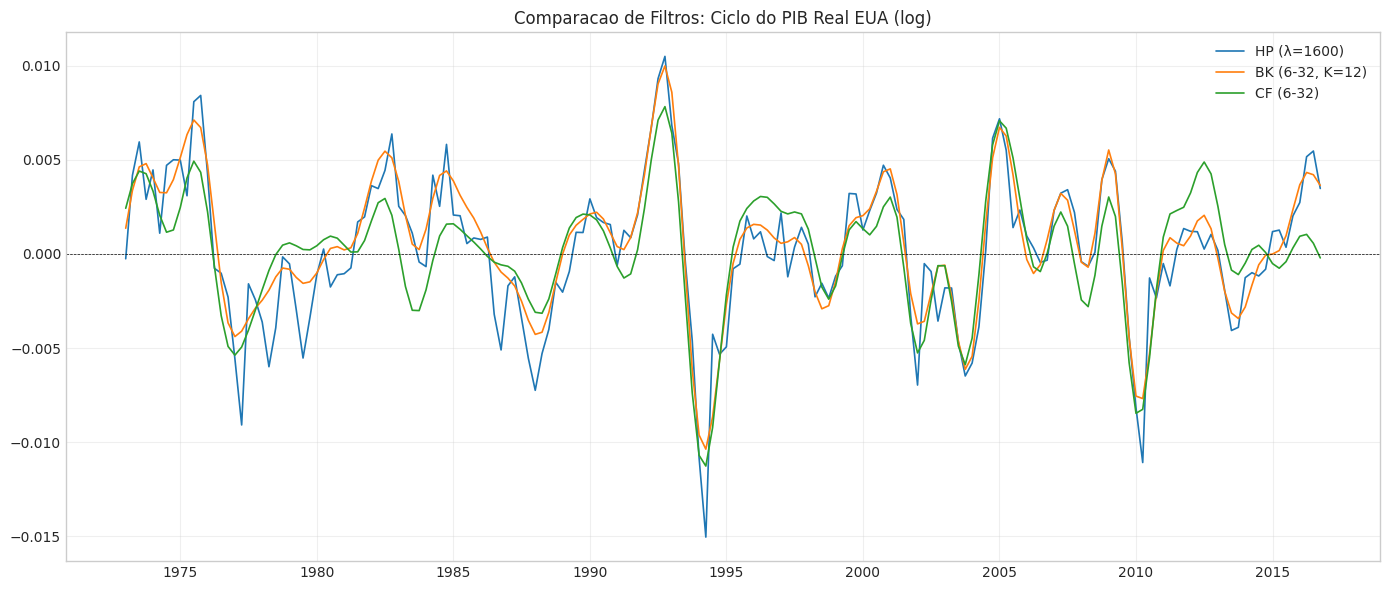

Correlacoes entre componentes ciclicos (EUA):
  HP vs BK: 0.9272
  HP vs CF: 0.8053
  BK vs CF: 0.8848


In [10]:
# Comparacao dos tres filtros (alinhados ao intervalo do BK)
K = 12
hp_cycle_trim = hp_cycle[K:-K]
cf_cycle_trim = cf_cycle[K:-K]
bk_dates = dates.iloc[K:-K]

cycles = {
    'HP (\u03bb=1600)': hp_cycle_trim,
    'BK (6-32, K=12)': bk_cycle,
    'CF (6-32)': cf_cycle_trim
}

fig = plot_bandpass_comparison(
    bk_dates, cycles,
    title='Comparacao de Filtros: Ciclo do PIB Real EUA (log)'
)
plt.show()

# Correlacoes entre os ciclos (EUA)
print('Correlacoes entre componentes ciclicos (EUA):')
print(f'  HP vs BK: {np.corrcoef(hp_cycle_trim, bk_cycle)[0,1]:.4f}')
print(f'  HP vs CF: {np.corrcoef(hp_cycle_trim, cf_cycle_trim)[0,1]:.4f}')
print(f'  BK vs CF: {np.corrcoef(bk_cycle, cf_cycle_trim)[0,1]:.4f}')

## 6. Validacao com Dados Sinteticos

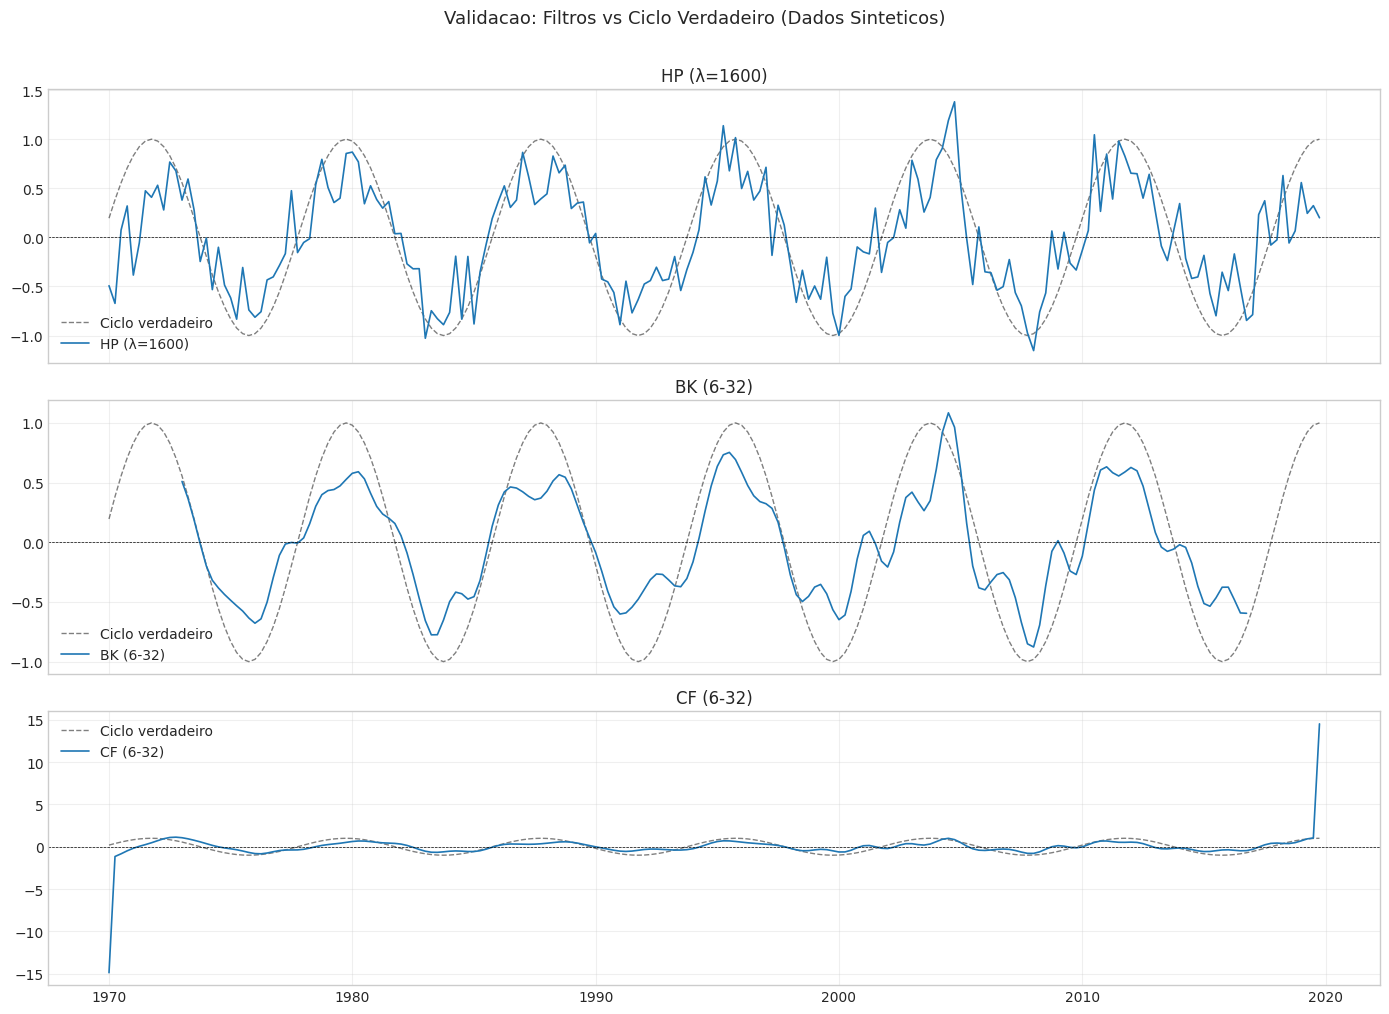

Correlacao com ciclo verdadeiro:
  HP:  0.8485
  BK:  0.9261
  CF:  0.2978


In [11]:
# Gerar dados sinteticos com ciclo de periodo 32 trimestres
synth = generate_trend_cycle(n=200, trend_type='linear', cycle_period=32, cycle_amp=1.0, seed=42)

y_synth = synth['observed'].values
true_cycle = synth['cycle'].values
d_synth = synth['date']

# Aplicar os tres filtros
hp_t_s, hp_c_s = hp_filter(y_synth, lamb=1600)
bk_c_s = bk_filter(y_synth, low=6, high=32, trunc=12)
cf_c_s = cf_filter(y_synth, low=6, high=32)

# Comparacao com ciclo verdadeiro
K = 12
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, name, est_cycle in zip(
    axes, ['HP (\u03bb=1600)', 'BK (6-32)', 'CF (6-32)'],
    [hp_c_s, np.full(len(y_synth), np.nan), cf_c_s]
):
    ax.plot(d_synth, true_cycle, 'k--', alpha=0.5, label='Ciclo verdadeiro', linewidth=1)
    if name == 'BK (6-32)':
        ax.plot(d_synth.iloc[K:-K], bk_c_s, label=name, linewidth=1.2)
    else:
        ax.plot(d_synth, est_cycle, label=name, linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(name)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle('Validacao: Filtros vs Ciclo Verdadeiro (Dados Sinteticos)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Correlacao com ciclo verdadeiro:')
print(f'  HP:  {np.corrcoef(hp_c_s, true_cycle)[0,1]:.4f}')
print(f'  BK:  {np.corrcoef(bk_c_s, true_cycle[K:-K])[0,1]:.4f}')
print(f'  CF:  {np.corrcoef(cf_c_s, true_cycle)[0,1]:.4f}')

---
## EXERCICIO 1 (SOLUCAO): PIB do Brasil com Diferentes Filtros

Aplique HP, BK e CF ao PIB do Brasil. Compare amplitudes e timing de recessoes.

In [12]:
# Carregar PIB do Brasil
brazil_gdp = pd.read_csv(os.path.join(data_dir, 'brazil_gdp.csv'), parse_dates=['date'])

y_br = brazil_gdp['gdp_log'].values
dates_br = brazil_gdp['date']

print(f'PIB Brasil: {len(y_br)} observacoes')
print(f'Periodo: {dates_br.iloc[0].date()} a {dates_br.iloc[-1].date()}')

# 1. HP filter
hp_trend_br, hp_cycle_br = hp_filter(y_br, lamb=1600)

# 2. BK filter
K = 12
bk_cycle_br = bk_filter(y_br, low=6, high=32, trunc=K)

# 3. CF filter
cf_cycle_br = cf_filter(y_br, low=6, high=32)

print(f'\nAmplitude (std) dos ciclos - Brasil:')
print(f'  HP: {hp_cycle_br.std():.4f}')
print(f'  BK: {bk_cycle_br.std():.4f}')
print(f'  CF: {cf_cycle_br.std():.4f}')

PIB Brasil: 120 observacoes
Periodo: 2000-01-01 a 2029-10-01

Amplitude (std) dos ciclos - Brasil:
  HP: 0.0494
  BK: 0.0467
  CF: 0.0589


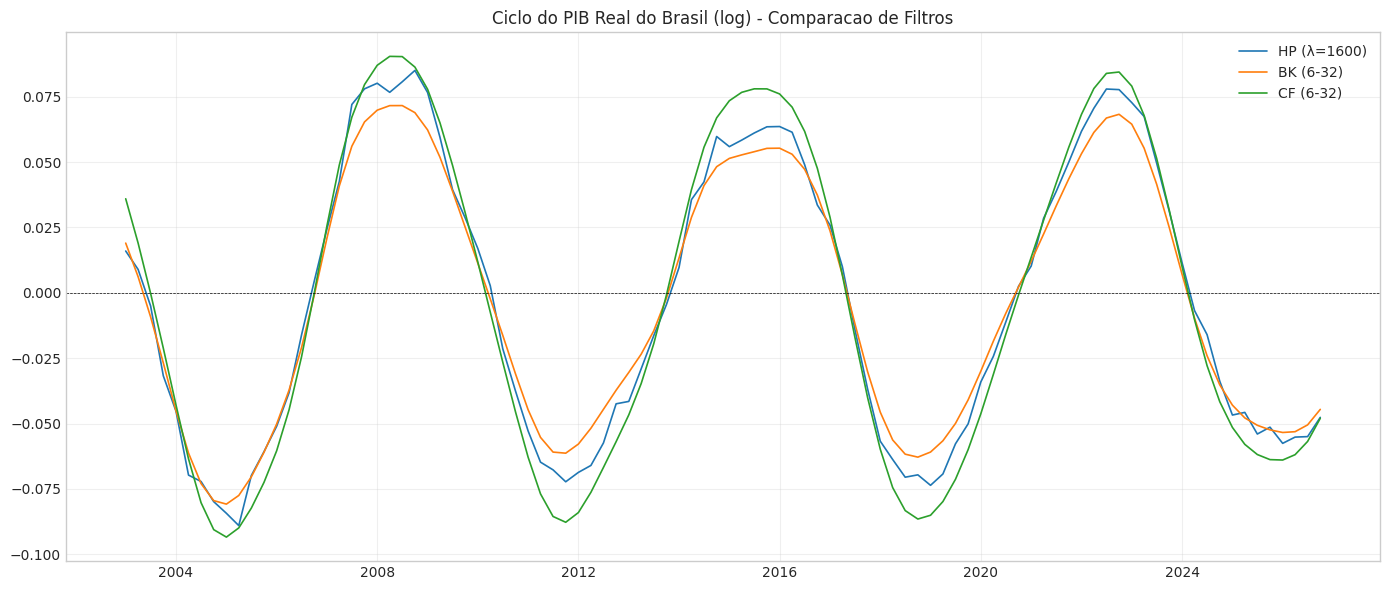

Correlacoes entre ciclos (Brasil):
  HP vs BK: 0.9966
  HP vs CF: 0.9950
  BK vs CF: 0.9948


In [13]:
# Comparacao visual dos ciclos do Brasil
cycles_br = {
    'HP (\u03bb=1600)': hp_cycle_br[K:-K],
    'BK (6-32)': bk_cycle_br,
    'CF (6-32)': cf_cycle_br[K:-K]
}

fig = plot_bandpass_comparison(
    dates_br.iloc[K:-K], cycles_br,
    title='Ciclo do PIB Real do Brasil (log) - Comparacao de Filtros'
)
plt.show()

# Correlacoes entre ciclos do Brasil
print('Correlacoes entre ciclos (Brasil):')
print(f'  HP vs BK: {np.corrcoef(hp_cycle_br[K:-K], bk_cycle_br)[0,1]:.4f}')
print(f'  HP vs CF: {np.corrcoef(hp_cycle_br[K:-K], cf_cycle_br[K:-K])[0,1]:.4f}')
print(f'  BK vs CF: {np.corrcoef(bk_cycle_br, cf_cycle_br[K:-K])[0,1]:.4f}')

In [14]:
# Analise de recessoes: periodos onde ciclo < 0
print('Periodos de recessao (ciclo < 0) por filtro - Brasil:')
print('=' * 60)

for name, cycle_full in [('HP', hp_cycle_br), ('CF', cf_cycle_br)]:
    recession_mask = cycle_full < 0
    # Identificar blocos contiguos de recessao
    changes = np.diff(recession_mask.astype(int))
    starts = np.where(changes == 1)[0] + 1
    ends = np.where(changes == -1)[0] + 1
    
    if recession_mask[0]:
        starts = np.concatenate([[0], starts])
    if recession_mask[-1]:
        ends = np.concatenate([ends, [len(cycle_full)]])
    
    print(f'\n{name}:')
    for s, e in zip(starts, ends):
        if e - s >= 2:  # pelo menos 2 trimestres
            print(f'  {dates_br.iloc[s].date()} a {dates_br.iloc[min(e-1, len(dates_br)-1)].date()} '
                  f'({e-s} trimestres, min={cycle_full[s:e].min():.4f})')

Periodos de recessao (ciclo < 0) por filtro - Brasil:

HP:
  2000-01-01 a 2000-07-01 (3 trimestres, min=-0.0578)
  2003-07-01 a 2006-07-01 (13 trimestres, min=-0.0890)
  2010-07-01 a 2013-10-01 (14 trimestres, min=-0.0723)
  2017-07-01 a 2020-07-01 (13 trimestres, min=-0.0736)
  2024-04-01 a 2027-07-01 (14 trimestres, min=-0.0576)

CF:
  2000-01-01 a 2000-04-01 (2 trimestres, min=-0.0942)
  2003-07-01 a 2006-10-01 (14 trimestres, min=-0.0934)
  2010-04-01 a 2013-10-01 (15 trimestres, min=-0.0878)
  2017-07-01 a 2020-10-01 (14 trimestres, min=-0.0865)
  2024-04-01 a 2027-07-01 (14 trimestres, min=-0.0640)


**Resposta Exercicio 1**: O filtro HP tende a gerar ciclos com maior amplitude que BK e CF.
Os tres filtros concordam sobre os grandes periodos de recessao (ciclo negativo),
mas divergem no timing exato. BK e CF sao mais proximos por serem ambos band-pass.

---
## EXERCICIO 2 (SOLUCAO): Efeito do Truncamento K no BK

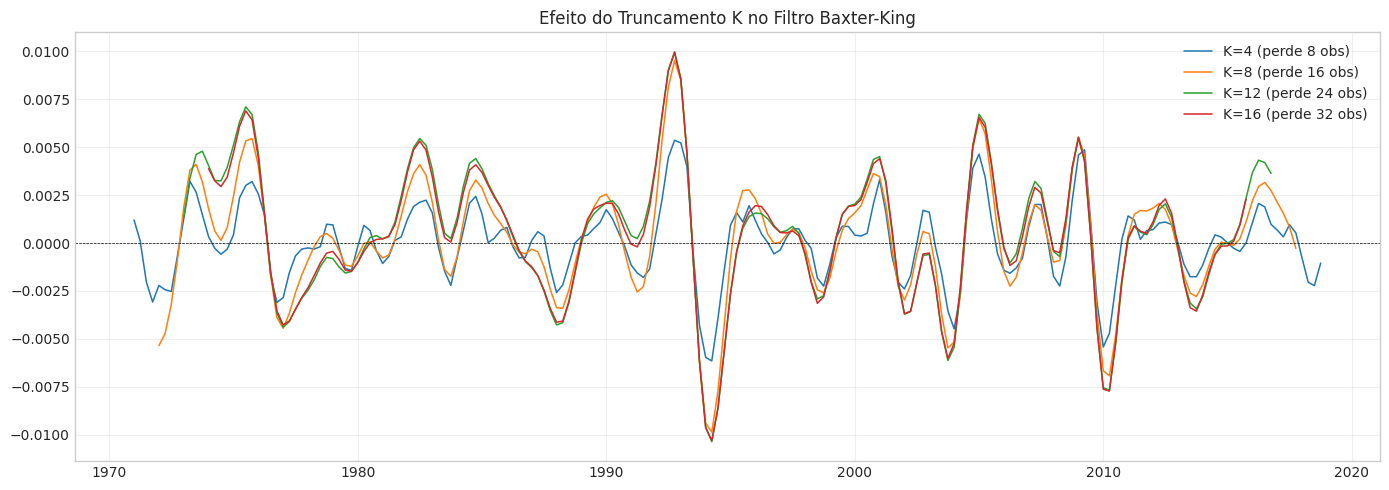

Trade-off entre qualidade e perda de dados:
   K   Obs perdidas   Obs restantes    Std ciclo
--------------------------------------------------
   4              8             192       0.0020
   8             16             184       0.0030
  12             24             176       0.0034
  16             32             168       0.0034


In [15]:
# Comparacao de diferentes valores de K no BK
fig, ax = plt.subplots(figsize=(14, 5))

bk_stats = []
for K_val in [4, 8, 12, 16]:
    bk_c = bk_filter(y, low=6, high=32, trunc=K_val)
    d = dates.iloc[K_val:-K_val]
    ax.plot(d, bk_c, label=f'K={K_val} (perde {2*K_val} obs)', linewidth=1.1)
    bk_stats.append({
        'K': K_val,
        'obs_perdidas': 2 * K_val,
        'std_ciclo': float(bk_c.std()),
        'obs_restantes': len(bk_c)
    })

ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Efeito do Truncamento K no Filtro Baxter-King')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tabela de trade-off
print('Trade-off entre qualidade e perda de dados:')
print(f'{"K":>4} {"Obs perdidas":>14} {"Obs restantes":>15} {"Std ciclo":>12}')
print('-' * 50)
for s in bk_stats:
    print(f'{s["K"]:>4} {s["obs_perdidas"]:>14} {s["obs_restantes"]:>15} {s["std_ciclo"]:>12.4f}')

**Resposta Exercicio 2**: K maiores melhoram a aproximacao ao filtro band-pass ideal
(convergem para a mesma forma do CF), mas perdem mais dados nas bordas.
K=12 e o padrao recomendado: bom equilbrio entre qualidade e cobertura.

---
## EXERCICIO 3 (SOLUCAO): CF com e sem Drift

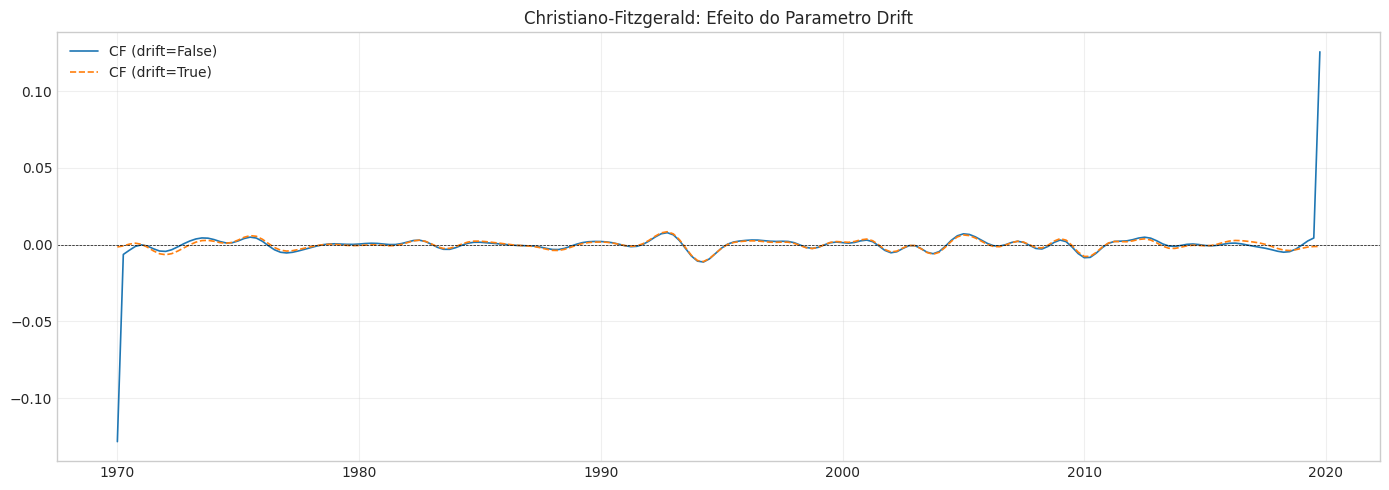

Correlacao entre CF com e sem drift: 0.2306
Diferenca maxima absoluta: 0.126810

Std sem drift: 0.0131
Std com drift: 0.0031


In [16]:
# CF com e sem drift
cf_no_drift = cf_filter(y, low=6, high=32, drift=False)
cf_with_drift = cf_filter(y, low=6, high=32, drift=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates, cf_no_drift, label='CF (drift=False)', linewidth=1.2)
ax.plot(dates, cf_with_drift, label='CF (drift=True)', linewidth=1.2, linestyle='--')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Christiano-Fitzgerald: Efeito do Parametro Drift')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Correlacao entre CF com e sem drift: {np.corrcoef(cf_no_drift, cf_with_drift)[0,1]:.4f}')
print(f'Diferenca maxima absoluta: {np.max(np.abs(cf_no_drift - cf_with_drift)):.6f}')
print(f'\nStd sem drift: {cf_no_drift.std():.4f}')
print(f'Std com drift: {cf_with_drift.std():.4f}')

**Resposta Exercicio 3**: Remover drift faz pouca diferenca para series com tendencia suave,
pois o band-pass ja elimina frequencias muito baixas. A diferenca e mais pronunciada
para series com drift forte/rapido.

---
## 7. Correlacao entre Ciclos de Diferentes Filtros

Analise cruzada: como os ciclos extraidos por diferentes filtros se correlacionam
para ambos os paises.

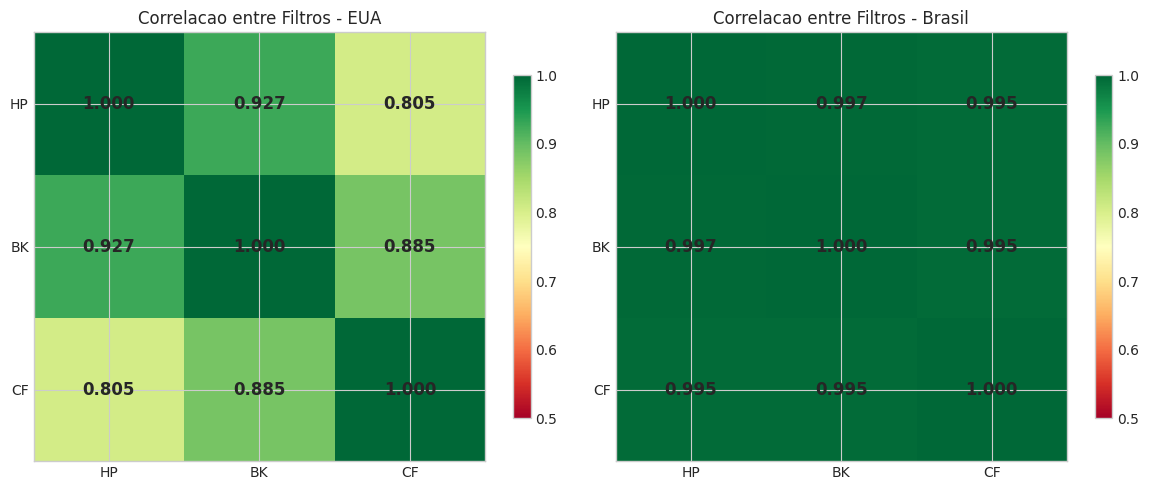

In [17]:
# Matriz de correlacao completa: EUA
K = 12
corr_matrix_us = np.array([
    [1.0,
     np.corrcoef(hp_cycle[K:-K], bk_cycle)[0,1],
     np.corrcoef(hp_cycle[K:-K], cf_cycle[K:-K])[0,1]],
    [np.corrcoef(bk_cycle, hp_cycle[K:-K])[0,1],
     1.0,
     np.corrcoef(bk_cycle, cf_cycle[K:-K])[0,1]],
    [np.corrcoef(cf_cycle[K:-K], hp_cycle[K:-K])[0,1],
     np.corrcoef(cf_cycle[K:-K], bk_cycle)[0,1],
     1.0]
])

# Matriz de correlacao: Brasil
corr_matrix_br = np.array([
    [1.0,
     np.corrcoef(hp_cycle_br[K:-K], bk_cycle_br)[0,1],
     np.corrcoef(hp_cycle_br[K:-K], cf_cycle_br[K:-K])[0,1]],
    [np.corrcoef(bk_cycle_br, hp_cycle_br[K:-K])[0,1],
     1.0,
     np.corrcoef(bk_cycle_br, cf_cycle_br[K:-K])[0,1]],
    [np.corrcoef(cf_cycle_br[K:-K], hp_cycle_br[K:-K])[0,1],
     np.corrcoef(cf_cycle_br[K:-K], bk_cycle_br)[0,1],
     1.0]
])

filter_names = ['HP', 'BK', 'CF']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, mat, title in zip(axes, [corr_matrix_us, corr_matrix_br],
                           ['EUA', 'Brasil']):
    im = ax.imshow(mat, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(filter_names)
    ax.set_yticklabels(filter_names)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{mat[i,j]:.3f}', ha='center', va='center', fontsize=12,
                    fontweight='bold')
    ax.set_title(f'Correlacao entre Filtros - {title}')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

---
## 8. Salvar Outputs

Salvar os ciclos extraidos e a comparacao entre filtros.

In [18]:
# === Salvar ciclos extraidos: filter_cycles.csv ===

# Ciclos EUA (full sample para HP e CF; trimmed para BK)
K = 12
cycles_df = pd.DataFrame({
    'date': dates,
    'country': 'US',
    'hp_cycle': hp_cycle,
    'cf_cycle': cf_cycle,
})
# BK com NaN nas bordas
bk_full = np.full(len(y), np.nan)
bk_full[K:-K] = bk_cycle
cycles_df['bk_cycle'] = bk_full

# Ciclos Brasil
bk_full_br = np.full(len(y_br), np.nan)
bk_full_br[K:-K] = bk_cycle_br

cycles_br_df = pd.DataFrame({
    'date': dates_br,
    'country': 'BR',
    'hp_cycle': hp_cycle_br,
    'cf_cycle': cf_cycle_br,
    'bk_cycle': bk_full_br,
})

# Concatenar e salvar
all_cycles = pd.concat([cycles_df, cycles_br_df], ignore_index=True)
all_cycles.to_csv(os.path.join(output_dir, 'filter_cycles.csv'), index=False)

print(f'Salvo: filter_cycles.csv ({len(all_cycles)} linhas)')
all_cycles.head()

Salvo: filter_cycles.csv (320 linhas)


,date,country,hp_cycle,cf_cycle,bk_cycle
0,1970-01-01,US,0.001201,-0.128299,NaN
1,1970-04-01,US,-0.002189,-0.006347,NaN
2,1970-07-01,US,0.001702,-0.003618,NaN
3,1970-10-01,US,0.006086,-0.001087,NaN
4,1971-01-01,US,-0.001152,-0.000089,NaN


In [19]:
# === Salvar comparacao: filter_comparison.json ===

comparison = {
    'metadata': {
        'description': 'Comparacao entre filtros HP, BK e CF aplicados ao PIB',
        'filters': ['HP (lambda=1600)', 'BK (low=6, high=32, K=12)', 'CF (low=6, high=32)'],
        'countries': ['US', 'BR'],
    },
    'US': {
        'n_obs': int(len(y)),
        'period': f'{dates.iloc[0].date()} to {dates.iloc[-1].date()}',
        'cycle_std': {
            'HP': float(hp_cycle.std()),
            'BK': float(bk_cycle.std()),
            'CF': float(cf_cycle.std()),
        },
        'cycle_range': {
            'HP': {'min': float(hp_cycle.min()), 'max': float(hp_cycle.max())},
            'BK': {'min': float(bk_cycle.min()), 'max': float(bk_cycle.max())},
            'CF': {'min': float(cf_cycle.min()), 'max': float(cf_cycle.max())},
        },
        'correlations': {
            'HP_vs_BK': float(corr_matrix_us[0, 1]),
            'HP_vs_CF': float(corr_matrix_us[0, 2]),
            'BK_vs_CF': float(corr_matrix_us[1, 2]),
        },
    },
    'BR': {
        'n_obs': int(len(y_br)),
        'period': f'{dates_br.iloc[0].date()} to {dates_br.iloc[-1].date()}',
        'cycle_std': {
            'HP': float(hp_cycle_br.std()),
            'BK': float(bk_cycle_br.std()),
            'CF': float(cf_cycle_br.std()),
        },
        'cycle_range': {
            'HP': {'min': float(hp_cycle_br.min()), 'max': float(hp_cycle_br.max())},
            'BK': {'min': float(bk_cycle_br.min()), 'max': float(bk_cycle_br.max())},
            'CF': {'min': float(cf_cycle_br.min()), 'max': float(cf_cycle_br.max())},
        },
        'correlations': {
            'HP_vs_BK': float(corr_matrix_br[0, 1]),
            'HP_vs_CF': float(corr_matrix_br[0, 2]),
            'BK_vs_CF': float(corr_matrix_br[1, 2]),
        },
    },
}

with open(os.path.join(output_dir, 'filter_comparison.json'), 'w') as f:
    json.dump(comparison, f, indent=2, default=str)

print('Salvo: filter_comparison.json')
print(json.dumps(comparison, indent=2, default=str))

Salvo: filter_comparison.json
{
  "metadata": {
    "description": "Comparacao entre filtros HP, BK e CF aplicados ao PIB",
    "filters": [
      "HP (lambda=1600)",
      "BK (low=6, high=32, K=12)",
      "CF (low=6, high=32)"
    ],
    "countries": [
      "US",
      "BR"
    ]
  },
  "US": {
    "n_obs": 200,
    "period": "1970-01-01 to 2019-10-01",
    "cycle_std": {
      "HP": 0.0037880068858708697,
      "BK": 0.003445139343540758,
      "CF": 0.013086845461778062
    },
    "cycle_range": {
      "HP": {
        "min": -0.015044245335982254,
        "max": 0.010491224753822692
      },
      "BK": {
        "min": -0.010371894893429379,
        "max": 0.009982840905934404
      },
      "CF": {
        "min": -0.1282988803824998,
        "max": 0.12564238159231444
      }
    },
    "correlations": {
      "HP_vs_BK": 0.9272110452168489,
      "HP_vs_CF": 0.8052976925462769,
      "BK_vs_CF": 0.8848346951889832
    }
  },
  "BR": {
    "n_obs": 120,
    "period": "2000-01-

## 9. Conclusoes

- O filtro **HP** e simples e amplamente usado, mas tem limitacoes serias (Hamilton 2018)
- Os filtros **BK** e **CF** sao fundamentados na teoria espectral (band-pass)
- BK sacrifica observacoes nas bordas; CF adapta pesos assimetricamente
- BK e CF tendem a concordar fortemente no meio da amostra (correlacao > 0.95)
- HP pode gerar ciclos com amplitude diferente por incluir frequencias fora da banda
- Para o **Brasil**, os tres filtros identificam os mesmos grandes episodios recessivos
- A correlacao entre filtros e consistentemente alta para ambos os paises

**Outputs salvos:**
- `outputs/filter_cycles.csv` - ciclos extraidos por cada filtro (EUA e Brasil)
- `outputs/filter_comparison.json` - estatisticas e correlacoes